In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import networkx as nx
import random
import heapq
import collections
from copy import deepcopy, copy

### All the simulation uses hours and kilometers

In [2]:
ARRIVAL_RATE = np.array([314.2, 162.4, 138.6, 148.8, 273.2, 1118.8, 2773.8, 4036.2, 4237.4, 3277.0, 2843.0, 2876.4, 3143.0, 3277.8, 3546.2, 4335.0, 4945.4, 4525.8, 2847.8, 1828.0, 1378.4, 1271.2, 1171.2, 767.6])
INCIDENT_RATE = np.array([0.1935483870967742, 0.25806451612903225, 0.2903225806451613, 0.1935483870967742, 0.06451612903225806, 0.967741935483871, 32.16129032258065, 131.03225806451613, 157.2258064516129, 48.32258064516129, 8.451612903225806, 6.258064516129032, 8.161290322580646, 10.290322580645162, 19.0, 65.7741935483871, 157.41935483870967, 163.3548387096774, 36.54838709677419, 3.7096774193548385, 1.2258064516129032, 0.8709677419354839, 0.5806451612903226, 0.41935483870967744])
INCIDENT_DURATION_PARAMS = (1.2294425495153518, 0.09878316410683122, 5.082687545787541)

CITY_A = '45098337'
CITY_B = '42995944'

incident_duration_dist = stats.lognorm(*INCIDENT_DURATION_PARAMS)

MEAN_ACCIDENT_DURATION = incident_duration_dist.expect()/60

In [3]:
#Sampling arrival times of cars to network
def lambdat(lambda_t, t : np.array):
    lambdat = []
    for time in t:
        lambdat.append(lambda_t[int(np.floor(time))])
    return lambdat

def arrival_times(lam): #Taken from lecture notes
    max_T = 24
    arrival_times = collections.deque()
    exp_dist = stats.expon(scale = 1/lam)
    t = exp_dist.rvs()
    while t < max_T:
        arrival_times.append(t)
        t += exp_dist.rvs()
    
    return np.asarray(arrival_times)

In [4]:
#Computing cofidence interval
def confidence_interval(mean, var, Nruns):
    zalpha2 = 1.96
    half_width = zalpha2 * np.sqrt(var)/np.sqrt(Nruns)
    ci = (mean - half_width, mean + half_width)
    return ci

def mean_var(array):
    return np.mean(array), np.var(array)

In [5]:
class FES:
    def __init__(self):
        self.events = []

    def add(self, event):
        heapq.heappush(self.events, event)
    
    def next(self):
        return heapq.heappop(self.events)
    
    def isEmpty(self):
        return len(self.events) == 0
    
    def __repr__(self):
        string = ''
        sorted_events = sorted(self.events)
        for event in sorted_events:
            string += f'{event}\n'
        return string

In [6]:
class Queue:
    def __init__(self, road):
        self.road = road
        self.cars = []

    def add(self, car, time):
        heapq.heappush(self.cars, car)
        car.enter_queue(time)

    def add_list(self, list, time):
        for car in list:
            heapq.heappush(self.cars, car)
            car.enter_queue(time)   

    def next(self):
        return heapq.heappop(self.cars)
    
    def first(self):
        return heapq.nsmallest(1, self.cars)
    
    def isEmpty(self):
        return len(self.cars) == 0
    
    def __repr__(self):
        string = ''
        sorted_cars = sorted(self.cars)
        for car in sorted_cars:
            string += f'{car}\n'
        return string

In [7]:
class Event:
    TYPE = ['New car', 'Car departure', 'Accident', 'Accident end', 'left queue']
    def __init__(self, typ:int, time, car = None, road = None, duration=None, location=None):
        #types:
            #0 : Arrival of car to the network
            #1 : Car leaves current road and goes on to the next
            #2 : Accident in road
            #3 : End of accident
            #4 : Departure of car from queue of accident
        self.type = typ
        self.time = time
        self.road = road
        self.location = location
        self.duration = duration
        self.cancelled = False

        if typ == 0:
            car = Car(time_entrance = time)
    
        self.car = car
        
    def __str__(self):
        if self.type == 0:
            return f'{self.TYPE[self.type]} from {self.car.origin} to {self.car.destination} at {self.time}'
        if self.type == 1:
            return f'{self.TYPE[self.type]} of {self.car} at {self.time}h'
        if self.type == 2:
            return f'{self.TYPE[self.type]} at {self.road} at {self.time}h'
        if self.type == 3:
            return f'{self.TYPE[self.type]} at {self.road} at {self.time}h'
        if self.type == 4:
            return f'{self.car} {self.TYPE[self.type]} at {self.road} at {self.time}h'

    def __lt__(self, other):
        return self.time < other.time
    
    def new_time(self, new_time):
        self.time = new_time

In [8]:
class Car:
    VELOCITIES = [100, 80]
    VELOCITIES_P = [0.9, 0.1]
    NAVIGATION_P = 0.5
    def __init__(self, time_entrance, origin = None, destination = None):
        #Origin and destination
        origin, destination = np.random.choice(JUNCTIONS, 2, replace = False)
        
        self.origin = origin
        self.destination = destination

        #path to follow
        self.path = nx.shortest_path(Graph, self.origin, self.destination, weight = 'length')

        #Velocity
        self.velocity = np.random.choice(self.VELOCITIES, p=self.VELOCITIES_P)

        #Variable to keep track how far into the path we are (to simplify scheduling events)
        #Int between 0 and len(path) - 1 that indicates in which edge we are, starting at 0
        #Essentially, how many edges has it travelled so far
        self.progress = 0
        
        #Give it nav with 10% chance
        self.has_nav = np.random.choice([True, False], p=[self.NAVIGATION_P, 1 - self.NAVIGATION_P])
        self.changed_route = []

        #Time entrance
        self.time = time_entrance
        self.time_entrance = time_entrance

        #keeping track of amount of accidents encountered
        self.accidents = 0
        self.next_event = None



    def __str__(self):
        return f'Vehicle travelling from {self.origin} to {self.destination} at {self.velocity} km/h, atm at {self.path[self.progress-1],self.path[self.progress]}, time {self.time}h'
    

    def custom_weight(self,u,v,data):
        """
        :param u: std for accepting function as weight, node 1
        :param v:  std for accepting function as weight, node 2
        :param data: std for accepting function as weight, edge
        :return: time_to_travel + delay
        """
        length = data['length']
        time_to_travel = (length / (self.velocity /3.6)) / 3600 #Mean of normal dist
        if Graph.edges[(u,v)]['accident']:   
            delay = MEAN_ACCIDENT_DURATION
        else:
            delay = 0
        return time_to_travel + delay
    
    def calc_time_to_travel(self,length):
        """
        :param length: edge length
        :return: returns time to traverse length based on normal speed
        """
        mean = length / (self.velocity /3.6) #seconds
        std = mean / 20
        time_to_travel = np.random.normal(loc = mean, scale = std) / 3600 #back to hours
        return max(0,time_to_travel)

    def schedule_event_exit(self):
        #Remove car from list of cars in previous edge
        if self.progress > 0:
            edge = (self.path[self.progress - 1], self.path[self.progress])
            DIC_EDGES[edge].remove(self)


        if self.progress < len(self.path) - 1:
            # Get the current and next node on the original path
            current_node = self.path[self.progress]
            next_node = self.path[self.progress + 1]
            edge = Graph.edges[(current_node, next_node)]

            # Check for accident on the current edge and if nav is enabled
            # No need to check for accident, just check if navigation (there may be accidents later that makes us recompute)
            if self.has_nav:
                # print("Updating path")
                new_path = nx.shortest_path(Graph, current_node, self.destination, weight=self.custom_weight)

                if new_path != self.path[self.progress:]:
                    # print("Found a quicker route")
                    # print(f"Prev path = {[Graph.nodes[node]['name'] for node in self.path]}")
                    # print(f"New path = {[Graph.nodes[node]['name'] for node in new_path]}")

                    #I commented this out bc append is not efficient
                    # self.changed_route.append((self.path, new_path))

                    # Preserve the already traversed portion
                    prefix = self.path[:self.progress]

                    updated_path = prefix + new_path
                    # print(updated_path)
                    # self.path = updated_path
                    # print(f"Updated path: {[Graph.nodes[node]['name'] for node in self.path]}")

                    # Update next_node based on the new path
                    next_node = self.path[self.progress + 1]
                    edge = Graph.edges[(current_node, next_node)]
                    length = edge['length']
                    # Sample travel time along the new edge (including accident delay)
                    
                    #I think no need to add accident duration bc i account for this in my code alr and a accident can happen before scheduling this
                    # time_to_travel = self.calc_time_to_travel(length) + edge['accident_duration']
                    time_to_travel = self.calc_time_to_travel(length)
                else:
                    # No change in path (fallback scenario)
                    length = edge['length']
                    time_to_travel = self.calc_time_to_travel(length)
            else:
                # Normal travel (no accident on the edge)
                length = edge['length']
                time_to_travel = self.calc_time_to_travel(length)

            new_time = self.time + time_to_travel
            # Schedule next event and update car's progress and time
            self.next_event = Event(1, new_time, car=self)
            # , road=(current_node, next_node))
            self.increase_progress()
            self.increase_time(new_time)

            #Add car to list of cars in the new edge
            # edge = (self.path[self.progress - 1], self.path[self.progress])
            DIC_EDGES[(current_node, next_node)].append(self)

            return self.next_event
    
    def increase_progress(self):
        self.progress += 1

    def increase_time(self, new_time):
        self.time = new_time

    def __lt__(self, other):
        return self.time < other.time
    
    def enter_queue(self, time):
        #store time at which the car entered the queue
        self.time_enter_q = time
        self.next_event.cancelled = True
        self.accidents += 1

    def exit_queue(self, time_exit):
        #Update time of car when it left the queue
        self.time += time_exit - self.time_enter_q
        # print(self.progress)
        new_event_exit = copy(self.next_event)
        # print(self.progress)
        new_event_exit.new_time(self.time)
        new_event_exit.cancelled = False
        # self.next_event.cancelled = True
        self.next_event = new_event_exit
        return new_event_exit
    
    def compute_path_length(self):
        length = 0
        if len(self.path) > 0:
            for n in range(len(self.path) - 1):
                edge = (self.path[n], self.path[n+1])
                length += Graph.edges[edge]['length']

            return length * 10**(-3) #back to km
        else:
            return 0.0

In [9]:
# road = list(DIC_EDGES.keys())[0]
# accident = Event(2, 0.5, road=road, duration=0.1, location=0.4)
# end_accident = Event(3, 0.6, road =road)
# fes.add(accident)
# fes.add(end_accident)
# # # road = road[::-1]
# # # accident = Event(2, 0.5, road=road)
# # # end_accident = Event(3, 0.6, road =road)
# # # fes.add(accident)
# # # fes.add(end_accident)

In [10]:
class SimulationData:

    def __init__(self):
        self.LIST_CARS = []
        self.LIST_TRUCKS = []
        self.LIST_VEHICLES = []
        self.LIST_CARS_AB = []

        self.LIST_AMOUNT_CARS_TRAFFIC_CHANGE = [0]
        self.LIST_AMOUNT_INCIDENTS_CHANGE = [0]
        self.TIME_ARRAY = []

In [15]:
class Simulation:

    
    def __init__(self, Nruns):
        self.nruns = Nruns
        self.data2 = [SimulationData() for _ in range(Nruns)]
        self.data3 = [SimulationData() for _ in range(Nruns)]
        self.data4 = [SimulationData() for _ in range(Nruns)]
        self.table_data2 = []
        self.table_data3 = []
        self.table_data4 = []
    
    def run_simulation3(self, iteration):
        data_storage = self.data3[iteration]
        #Using a thining approach to get arrival times
        max_lambda = np.max(ARRIVAL_RATE) + 1
        all_arrivals = arrival_times(max_lambda)

        uniform_dist = stats.uniform(0,1)
        u_rvs = uniform_dist.rvs(len(all_arrivals))
        accept_filter = u_rvs * max_lambda < lambdat(ARRIVAL_RATE, all_arrivals)

        accepted_arrivals = all_arrivals[accept_filter]

        #Using a thining approach to get accident times
        max_lambda = np.max(INCIDENT_RATE) + 1
        all_accidents = arrival_times(max_lambda)

        uniform_dist = stats.uniform(0,1)
        u_rvs = uniform_dist.rvs(len(all_accidents))
        accept_filter = u_rvs * max_lambda < lambdat(INCIDENT_RATE, all_accidents)

        accepted_accidents = all_accidents[accept_filter]

        global Graph
        Graph = nx.read_gml('./data/networkAssignment.gml')
        Graph = Graph.to_directed()

        global JUNCTIONS
        JUNCTIONS = list(Graph.nodes)

        global DIC_EDGES
        DIC_EDGES = {}
        #Dictionary that keeps track on when the last accident ends in a road before another one can take place
        DIC_ACCIDENTS = {}
        for edge in Graph.edges:
            DIC_EDGES[edge] = []
            DIC_ACCIDENTS[edge] = 0
            #Associate departure from queue distribution to each edge based on number of lanes
            rate = 0.2/(60 * Graph.edges[edge]['lanes'])
            Graph.edges[edge]['DepDist'] = stats.expon(scale = rate)

            Graph.edges[edge]['accident'] = False
            Graph.edges[edge]['queue'] = False
            # Graph.edges[edge]['accident_duration'] = 0

        #Simulation (can be turned into an object later)
        # LIST_CARS = []
        # LIST_AMOUNT_CARS_TRAFFIC_CHANGE = [0]
        # LIST_AMOUNT_INCIDENTS_CHANGE = [0]
        # TIME_ARRAY = []
        fes = FES()
        for arrival in accepted_arrivals:
            #Two events associated with each arrival
            arrival_event = Event(0, arrival)
            fes.add(arrival_event)

        for accident in accepted_accidents:
            affected_road = list(Graph.edges)[np.random.choice(len(Graph.edges))]
            if DIC_ACCIDENTS[affected_road] < accident:
                location = stats.uniform.rvs()
                duration = incident_duration_dist.rvs()/60
                time_end = accident + duration
                accident_event = Event(2, accident, road=affected_road, duration=duration, location=location)
                end_accident = Event(3, time_end, road=affected_road)

                fes.add(accident_event)
                fes.add(end_accident)
                DIC_ACCIDENTS[affected_road] = time_end
        # heapq.heapify(fes.events)
        #Queue for accidents setup
        Queues = {}
        for edge in DIC_EDGES.keys():
            Queues[edge] = Queue(edge)
            
        t = 0 #current time
        step = 0
        while t < 24.0:
            event = fes.next()
            if not(event.cancelled):
                if t> event.time:
                    print('OH OH OH OH')
                    print(event)
                t = event.time
                data_storage.TIME_ARRAY.append(t)
                
                
                # print(t)
                #Car joins network
                if event.type == 0:
                    
                    car = event.car
                    
                    #Schedule next event and store it as attribute
                    car.next_event = car.schedule_event_exit()
                    car_travel_event = car.next_event
                    if car_travel_event.time <= t:
                        print('Problem 0')
                    fes.add(car_travel_event)

                    #Data storage
                    data_storage.LIST_VEHICLES.append(car)
                    if car.velocity == 80:
                        data_storage.LIST_TRUCKS.append(car)
                    elif car.velocity == 100:
                        data_storage.LIST_CARS.append(car)
                        
                        if car.origin == CITY_A and car.destination == CITY_B:
                            data_storage.LIST_CARS_AB.append(car)

                    data_storage.LIST_AMOUNT_CARS_TRAFFIC_CHANGE.append(0)
                    data_storage.LIST_AMOUNT_INCIDENTS_CHANGE.append(0)

                #Car leaves road
                if event.type == 1:
                    
                    car = event.car
                    # print(car.progress)
                    # print(car in DIC_EDGES[(car.path[car.progress - 1], car.path[car.progress])])
                    # print(car)
                    next_travel_event_car = car.schedule_event_exit()
                    if type(next_travel_event_car) == Event: #If the car has arrived to its destination it wont return an event object
                        if next_travel_event_car.time < t:
                            print('Problem 1')
                        fes.add(next_travel_event_car)
                        road = (car.path[car.progress -1], car.path[car.progress])
                        if Graph.edges[road]['queue'] or Graph.edges[road]['accident']:
                            Queues[road].add_list([car], event.time)
                            data_storage.LIST_AMOUNT_CARS_TRAFFIC_CHANGE.append(1)
                        else:
                            data_storage.LIST_AMOUNT_CARS_TRAFFIC_CHANGE.append(0)
                    data_storage.LIST_AMOUNT_INCIDENTS_CHANGE.append(0)
                            
                        
                    
                    # else:
                        # print(event.car)

                #Start accident
                if event.type == 2:
                    road = event.road
                    data_storage.LIST_AMOUNT_INCIDENTS_CHANGE.append(1)
                    #choose random cars affected:
                        #List comprehension is inefficient af here
                        # cars_not_in_queue = [car for car in DIC_EDGES[road] if car not in Queues[road].cars]
                    cars_not_in_queue = sorted(list(set(DIC_EDGES[road]) - set(Queues[road].cars)))
                    if len(cars_not_in_queue) != 0:
                        amount_cars_affected = int(np.floor(event.location * len(cars_not_in_queue)))
                        data_storage.LIST_AMOUNT_CARS_TRAFFIC_CHANGE.append(amount_cars_affected)
                        cars_affected = cars_not_in_queue[:amount_cars_affected]

                        # print(f'Time enter queue {event.time}')
                        Queues[road].add_list(cars_affected, event.time)
                        
                    Graph.edges[road]['accident'] = True

                    #Assuming end of accident event is already created, else create here
                    # print(f'{t}')

                #End accident
                if event.type == 3:
                    data_storage.LIST_AMOUNT_INCIDENTS_CHANGE.append(-1)
                    road = event.road
                    #1 minute until first car leaves the queue 
                    if not(Queues[road].isEmpty()) and not(Graph.edges[road]['queue']):
                        # print(Queues[road])
                        # print(f'First event departure {Queues[road].isEmpty()}', road)
                        first_departure_event = Event(4, event.time, road=road)
                        # print(first_departure_event)
                        fes.add(first_departure_event)
                        if first_departure_event.time < t:
                            print('Problem 3')
                        Graph.edges[road]['queue'] = True
                    Graph.edges[road]['accident'] = False   
                    # print(t)
                    data_storage.LIST_AMOUNT_CARS_TRAFFIC_CHANGE.append(0)
                # 
                #Departure from queue
                if event.type == 4:
                    
                    # print(event)
                    road = event.road
                    time = event.time
                    #Remove car from queue
                    # print(len(Queues[road].cars), event.road)
                    car = Queues[road].next()
                    data_storage.LIST_AMOUNT_CARS_TRAFFIC_CHANGE.append(-1)
                    data_storage.LIST_AMOUNT_INCIDENTS_CHANGE.append(0)
                    # print(car.progress)
                    #Modify time to arrival of next node in path
                    # print(f'Time exit queue {event.time}')
                    # print(f'Previous event at {car.time}')
                    new_event_exit = car.exit_queue(time)
                    # print(f'New event at {new_event_exit.time}')
                    fes.add(new_event_exit)
                    # print(f'Equivalent cars {car1==car}')
                    # print(car in DIC_EDGES[(car.path[car.progress - 1], car.path[car.progress])])
                    # heapq.heapify(fes.events)

                    if not(Queues[road].isEmpty()):
                        #Next departure event
                        next_event_time = time + Graph.edges[road]['DepDist'].rvs()
                        
                        next_event = Event(4, next_event_time, road=road)
                        if next_event.time < t:
                            print('Problem 4')
                        # print(next_event)
                        fes.add(next_event)
                    else:
                        Graph.edges[road]['queue'] = False

                # heapq.heapify(fes.events)
                # print(t)
                step += 1

    def run_simulation2(self, iteration):
        data_storage = self.data2[iteration]
        #Using a thining approach to get arrival times
        max_lambda = np.max(ARRIVAL_RATE) + 1
        all_arrivals = arrival_times(max_lambda)

        uniform_dist = stats.uniform(0,1)
        u_rvs = uniform_dist.rvs(len(all_arrivals))
        accept_filter = u_rvs * max_lambda < lambdat(ARRIVAL_RATE, all_arrivals)

        accepted_arrivals = all_arrivals[accept_filter]

        global Graph
        Graph = nx.read_gml('./data/networkAssignment.gml')
        Graph = Graph.to_directed()

        global JUNCTIONS
        JUNCTIONS = list(Graph.nodes)

        global DIC_EDGES
        DIC_EDGES = {}

        for edge in Graph.edges:
            DIC_EDGES[edge] = []
            Graph.edges[edge]['accident'] = False
            Graph.edges[edge]['queue'] = False
            # Graph.edges[edge]['accident_duration'] = 0

        #Simulation (can be turned into an object later)
        # LIST_CARS = []
        # LIST_AMOUNT_CARS_TRAFFIC_CHANGE = [0]
        # LIST_AMOUNT_INCIDENTS_CHANGE = [0]
        # TIME_ARRAY = []
        fes = FES()
        for arrival in accepted_arrivals:
            #Two events associated with each arrival
            arrival_event = Event(0, arrival)
            fes.add(arrival_event)
        # heapq.heapify(fes.events)
            
        t = 0 #current time
        step = 0
        while t < 24.0:
            event = fes.next()
            if not(event.cancelled):
                if t> event.time:
                    print('OH OH OH OH')
                    print(event)
                t = event.time
                data_storage.TIME_ARRAY.append(t)
                
                
                # print(t)
                #Car joins network
                if event.type == 0:
                    
                    car = event.car
                    
                    #Schedule next event and store it as attribute
                    car.next_event = car.schedule_event_exit()
                    car_travel_event = car.next_event
                    if car_travel_event.time <= t:
                        print('Problem 0')
                    fes.add(car_travel_event)

                    #Data storage
                    data_storage.LIST_VEHICLES.append(car)
                    if car.velocity == 80:
                        data_storage.LIST_TRUCKS.append(car)
                    elif car.velocity == 100:
                        data_storage.LIST_CARS.append(car)
                        
                        if car.origin == CITY_A and car.destination == CITY_B:
                            data_storage.LIST_CARS_AB.append(car)

                    data_storage.LIST_AMOUNT_CARS_TRAFFIC_CHANGE.append(0)
                    data_storage.LIST_AMOUNT_INCIDENTS_CHANGE.append(0)

                #Car leaves road
                if event.type == 1:
                    
                    car = event.car
                    # print(car.progress)
                    # print(car in DIC_EDGES[(car.path[car.progress - 1], car.path[car.progress])])
                    # print(car)
                    next_travel_event_car = car.schedule_event_exit()
                    if type(next_travel_event_car) == Event: #If the car has arrived to its destination it wont return an event object
                        if next_travel_event_car.time < t:
                            print('Problem 1')
                        fes.add(next_travel_event_car)

                    data_storage.LIST_AMOUNT_CARS_TRAFFIC_CHANGE.append(0)
                    data_storage.LIST_AMOUNT_INCIDENTS_CHANGE.append(0)
                            
                        
                # heapq.heapify(fes.events)
                # print(t)
                step += 1

    def compute_all_data3(self):
        for n in range(self.nruns):
            self.run_simulation3(n)


    def compute_all_data2(self):
        for n in range(self.nruns):
            self.run_simulation2(n)


    def compute_table3(self):
        global Graph 
        Graph = nx.read_gml('./data/networkAssignment.gml')
        Graph = Graph.to_directed()

        data = self.data3

        mean_std_list = []

        total_num_vehicles = np.array([len(data[n].LIST_VEHICLES) for n in range(self.nruns)])
        mean, var = mean_var(total_num_vehicles)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_num_vehicles = confidence_interval(mean, var, self.nruns)
        
        # [np.mean([self.data[n].LIST_CARS[m].time - self.data[n].LIST_CARS[m].time_entrance for m in range(len(self.data[n].LIST_CARS)) if self.data[n].LIST_CARS[m].progress == len(self.data[n].LIST_CARS[m].path)-1 ]) for n in self.nruns]
            
        travel_time_any = np.array([np.mean([data[n].LIST_VEHICLES[m].time - data[n].LIST_VEHICLES[m].time_entrance for m in range(len(data[n].LIST_VEHICLES)) if data[n].LIST_VEHICLES[m].progress == len(data[n].LIST_VEHICLES[m].path)-1 ]) for n in range(self.nruns)]) * 60
        mean, var = mean_var(travel_time_any)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_travel_time_any  = confidence_interval(mean, var, self.nruns)

        travel_time_trucks = np.array([np.mean([data[n].LIST_TRUCKS[m].time - data[n].LIST_TRUCKS[m].time_entrance for m in range(len(data[n].LIST_TRUCKS)) if data[n].LIST_TRUCKS[m].progress == len(data[n].LIST_TRUCKS[m].path)-1 ]) for n in range(self.nruns)]) * 60
        mean, var = mean_var(travel_time_trucks)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_travel_time_trucks = confidence_interval(mean, var, self.nruns)

        travel_time_cars = np.array([np.mean([data[n].LIST_CARS[m].time - data[n].LIST_CARS[m].time_entrance for m in range(len(data[n].LIST_CARS)) if data[n].LIST_CARS[m].progress == len(data[n].LIST_CARS[m].path)-1 ]) for n in range(self.nruns)]) * 60
        mean, var = mean_var(travel_time_cars)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_travel_time_cars = confidence_interval(mean, var, self.nruns)

        travel_time_cars_ab = np.array([np.mean([data[n].LIST_CARS_AB[m].time - data[n].LIST_CARS_AB[m].time_entrance for m in range(len(data[n].LIST_CARS_AB)) if data[n].LIST_CARS_AB[m].progress == len(data[n].LIST_CARS_AB[m].path)-1 ]) for n in range(self.nruns)]) * 60
        mean, var = mean_var(travel_time_cars_ab)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_travel_time_cars_ab = confidence_interval(mean, var, self.nruns)
        
        route_length = np.array([np.mean([data[n].LIST_VEHICLES[m].compute_path_length() for m in range(len(data[n].LIST_VEHICLES))]) for n in range(self.nruns)])
        mean, var = mean_var(route_length)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_route_length = confidence_interval(mean, var, self.nruns)

        self.table_data = [ci_num_vehicles, ci_travel_time_any, ci_travel_time_trucks, ci_travel_time_cars, ci_travel_time_cars_ab, ci_route_length]

        names = ['Total Number of Vehicles', 'Travel time (arbitrary vehicle)', 'Travel time truck', 'Travel time car', 'Travel time from A to B (car)', 'Route length']
        print('Q3: Times in min, Distances in km\n')
        for m, name in enumerate(names):
            print(f'{name}: mean: {mean_std_list[m][0]}, std : {mean_std_list[m][1]}, ci 95%: {self.table_data[m]}\n')

    def compute_table2(self):
        global Graph 
        Graph = nx.read_gml('./data/networkAssignment.gml')
        Graph = Graph.to_directed()

        data = self.data2

        mean_std_list = []

        total_num_vehicles = np.array([len(data[n].LIST_VEHICLES) for n in range(self.nruns)])
        mean, var = mean_var(total_num_vehicles)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_num_vehicles = confidence_interval(mean, var, self.nruns)
        
        # [np.mean([self.data[n].LIST_CARS[m].time - self.data[n].LIST_CARS[m].time_entrance for m in range(len(self.data[n].LIST_CARS)) if self.data[n].LIST_CARS[m].progress == len(self.data[n].LIST_CARS[m].path)-1 ]) for n in self.nruns]
            
        travel_time_any = np.array([np.mean([data[n].LIST_VEHICLES[m].time - data[n].LIST_VEHICLES[m].time_entrance for m in range(len(data[n].LIST_VEHICLES)) if data[n].LIST_VEHICLES[m].progress == len(data[n].LIST_VEHICLES[m].path)-1 ]) for n in range(self.nruns)]) * 60
        mean, var = mean_var(travel_time_any)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_travel_time_any  = confidence_interval(mean, var, self.nruns)

        travel_time_trucks = np.array([np.mean([data[n].LIST_TRUCKS[m].time - data[n].LIST_TRUCKS[m].time_entrance for m in range(len(data[n].LIST_TRUCKS)) if data[n].LIST_TRUCKS[m].progress == len(data[n].LIST_TRUCKS[m].path)-1 ]) for n in range(self.nruns)]) * 60
        mean, var = mean_var(travel_time_trucks)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_travel_time_trucks = confidence_interval(mean, var, self.nruns)

        travel_time_cars = np.array([np.mean([data[n].LIST_CARS[m].time - data[n].LIST_CARS[m].time_entrance for m in range(len(data[n].LIST_CARS)) if data[n].LIST_CARS[m].progress == len(data[n].LIST_CARS[m].path)-1 ]) for n in range(self.nruns)]) * 60
        mean, var = mean_var(travel_time_cars)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_travel_time_cars = confidence_interval(mean, var, self.nruns)

        travel_time_cars_ab = np.array([np.mean([data[n].LIST_CARS_AB[m].time - data[n].LIST_CARS_AB[m].time_entrance for m in range(len(data[n].LIST_CARS_AB)) if data[n].LIST_CARS_AB[m].progress == len(data[n].LIST_CARS_AB[m].path)-1 ]) for n in range(self.nruns)]) * 60
        mean, var = mean_var(travel_time_cars_ab)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_travel_time_cars_ab = confidence_interval(mean, var, self.nruns)
        
        route_length = np.array([np.mean([data[n].LIST_VEHICLES[m].compute_path_length() for m in range(len(data[n].LIST_VEHICLES))]) for n in range(self.nruns)])
        mean, var = mean_var(route_length)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_route_length = confidence_interval(mean, var, self.nruns)

        self.table_data = [ci_num_vehicles, ci_travel_time_any, ci_travel_time_trucks, ci_travel_time_cars, ci_travel_time_cars_ab, ci_route_length]

        names = ['Total Number of Vehicles', 'Travel time (arbitrary vehicle)', 'Travel time truck', 'Travel time car', 'Travel time from A to B (car)', 'Route length']
        print('Q2: Times in min, Distances in km\n')
        for m, name in enumerate(names):
            print(f'{name}: mean: {mean_std_list[m][0]}, std : {mean_std_list[m][1]}, ci 95%: {self.table_data[m]}\n')

    def plot_hist2(self):
        data = self.data2
        travel_time_cars_ab = np.array([np.mean([data[n].LIST_CARS_AB[m].time - data[n].LIST_CARS_AB[m].time_entrance for m in range(len(data[n].LIST_CARS_AB)) if data[n].LIST_CARS_AB[m].progress == len(data[n].LIST_CARS_AB[m].path)-1 ]) for n in range(self.nruns)]) * 60
        plt.hist(travel_time_cars_ab)
        plt.show()

Q2: Times in min, Distances in km

Total Number of Vehicles: mean: 55013.5, std : 74.5, ci 95%: (54910.24826781114, 55116.75173218886)

Travel time (arbitrary vehicle): mean: 32.94459533975186, std : 0.12394436671010212, ci 95%: (32.77281721145831, 33.1163734680454)

Travel time truck: mean: 40.24696378699862, std : 0.0073395225784231855, ci 95%: (40.23679172767431, 40.25713584632293)

Travel time car: mean: 32.140186450108146, std : 0.13405215867044618, ci 95%: (31.954399636868153, 32.32597326334814)

Travel time from A to B (car): mean: 52.51224977544322, std : 0.04620461096520856, ci 95%: (52.44821345172148, 52.57628609916497)

Route length: mean: 53.68035185205453, std : 0.200528684541478, ci 95%: (53.402433274437605, 53.95827042967145)



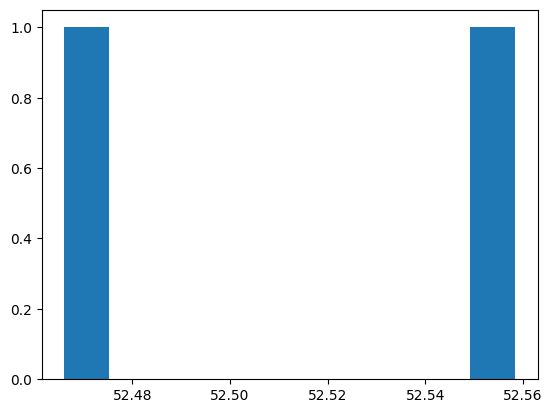

In [16]:
sim_try = Simulation(2)
sim_try.compute_all_data2()
sim_try.compute_table2()
sim_try.plot_hist2()